# Figure S4

In [ ]:
%%bash
### # Combine UHGV HQ + uncertain genomes
# # combine UHGV HQ + uncertain genomes with UHGV HQ+ confident genomes to make UHVDB HQ+ genomes
# wget https://portal.nersc.gov/cfs/m342/UHGV/genome_catalogs/uhgv_full.fna.gz

# seqkit grep \
#     uhgv_full.fna.gz \
#     --pattern-file uhgv_hq_plus_uncertain.tsv \
#     --out-file uhgv_hq_plus_uncertain.fna.gz

# wget https://portal.nersc.gov/cfs/m342/UHGV/genome_catalogs/uhgv_hq_plus.fna.gz

# cat uhgv_hq_plus.fna.gz \
#     uhgv_hq_plus_uncertain.fna.gz \
#     > uhgv_hq_plus_confident_w_uncertain.fna.gz

In [ ]:
%%bash
# # run seqhasher to dereplicate genomes
# /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhgdb/bin/seq-hasher \
#     uhgv_hq_plus_confident_w_uncertain.fna.gz \
#     --multi-kmer-hashing \
#     --circular-kmers \
#     > uhgv_hq_plus_confident_w_uncertain.seq-hasher.tsv

# # identify unique sequences
# csvtk uniq \
#     uhgv_hq_plus_confident_w_uncertain.seq-hasher.tsv \
#     --no-header-row \
#     --fields 2 \
#     --tabs \
#     --out-file uhgv_hq_plus_confident_w_uncertain.uniq.tsv

# # extract unique sequences
# csvtk cut \
#     --tabs \
#     uhgv_hq_plus_confident_w_uncertain.uniq.tsv \
#     --fields 1 \
#     --out-file uhvdb.unique_pattern.tsv

# seqkit \
#     grep \
#     --threads 2 \
#     --pattern-file uhgv_hq_plus_confident_w_uncertain.unique_pattern.tsv \
#     uhgv_hq_plus_confident_w_uncertain.fna.gz \
#     -o uhgv_hq_plus_confident_w_uncertain.unique.fna.gz

In [ ]:
%%bash
# # align all-v-all using UHGV
# vclust \
#     prefilter \
#     --in uhgv_hq_plus_confident_w_uncertain.unique.fna.gz \
#     --out uhvdb.vclust_votu_prefilter.txt \
#     --threads 72 \
#     --min-ident 0.95

# vclust \
#     align \
#     --in uhgv_hq_plus_confident_w_uncertain.unique.fna.gz \
#     --out uhgv_hq_plus_confident_w_uncertain.vclust_votu_ani.tsv \
#     --filter uhgv_hq_plus_confident_w_uncertain.vclust_votu_prefilter.txt \
#     --threads 72 \
#     --out-ani 0.95 \
#     --out-qcov 0.85

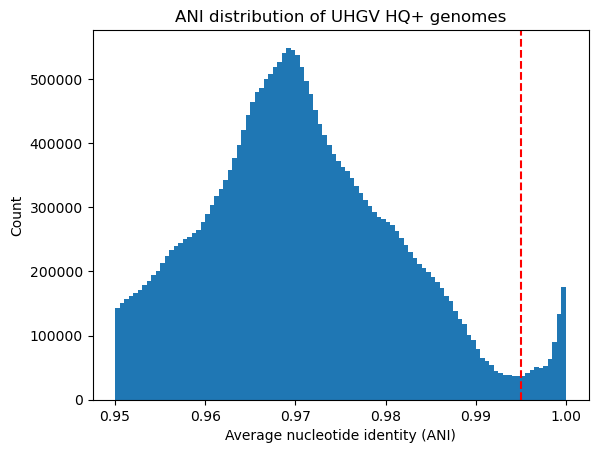

In [ ]:
### plot ANI distribution 
import polars as pl
import matplotlib.pyplot as plt

ani = pl.read_csv("uhgv_hq_plus_confident_w_uncertain.vclust_votu_ani.tsv.gz", separator="\t")

plt.axvline(x=0.995, color="red", linestyle="--")
plt.hist(ani["ani"], bins=100)
plt.title("ANI distribution of UHGV HQ+ genomes")
plt.xlabel("Average nucleotide identity (ANI)")
plt.ylabel("Count")

plt.show()

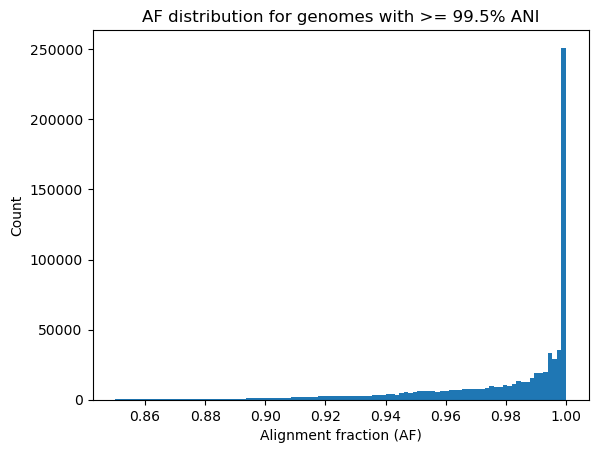

In [ ]:
### plot AF (relative to query) distribution for genomes with >= 99.5% ANI
plt.hist(ani.filter(pl.col('ani') >= 0.995)['qcov'], bins=100)
plt.title("AF distribution for genomes with >= 99.5% ANI")
plt.xlabel("Alignment fraction (AF)")
plt.ylabel("Count")
plt.show()

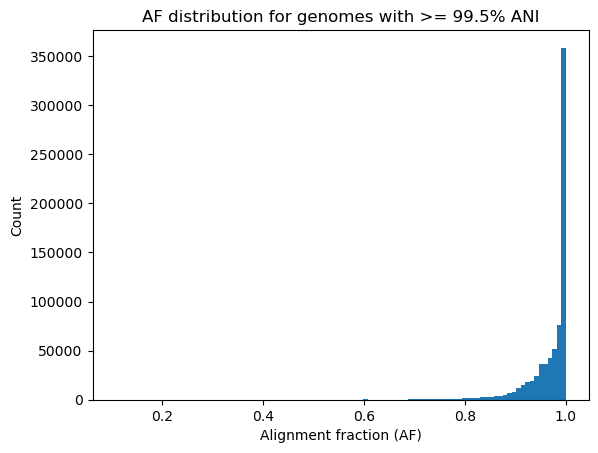

In [ ]:
### plot AF (relative to reference) distribution for genomes with >= 99.5% ANI
plt.hist(ani.filter(pl.col('ani') >= 0.995)['rcov'], bins=100)
plt.title("AF distribution for genomes with >= 99.5% ANI")
plt.xlabel("Alignment fraction (AF)")
plt.ylabel("Count")
plt.show()